# 19 — Proposal figure: single panel, real image

**Three cells to run in order:**
1. **Setup** — run once per session
2. **Params** — stretch, grating angle, compass position, grating position/size
3. **Plot** — re-run after any param change

**Kernel:** `Python (spectrangle WSL)`


---
## Cell 1 · Setup  _(run once)_


In [39]:
import sys, shutil, warnings, time, platform, pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.ndimage import gaussian_filter
from astropy.io import fits
from astropy.wcs import WCS, FITSFixedWarning

_pkg = str(Path('..').resolve())
if _pkg not in sys.path:
    sys.path.insert(0, _pkg)

from extractor import extract_stars
from extractor.platesolve import solve_plate, LocalSolveFieldError
from extractor.wcsangle import center_wcs_angle_metrics

# ── Paths ─────────────────────────────────────────────────────────────────────
IMAGE_FILE = Path('..') / 'data' / 'fig' / 'fuji6_asi178_100_15s.fit'
OUT_DIR    = Path('..') / 'out' / 'proposal_fig_real'
OUT_DIR.mkdir(parents=True, exist_ok=True)
NB10_FID   = Path('..') / 'out' / 'local_bootstrap_10' / 'fiducial_result.pkl'
NB10_SRC   = Path('..') / 'out' / 'local_bootstrap_10' / 'sources.pkl'
SRC_CACHE  = OUT_DIR / 'sources.pkl'
FID_CACHE  = OUT_DIR / 'fiducial.pkl'
FIG_OUT    = OUT_DIR / 'proposal_real_v2.png'
BACKEND_CFG = '/mnt/c/Users/bassd/.astrometry/backend.cfg'
INDEX_DIR   = Path('/mnt/c/Users/bassd/astrometry-data/4100/')

# ── Fixed figure style ────────────────────────────────────────────────────────
CMAP          = 'gray'
FIG_W, FIG_H  = 11.0, 7.5
FIG_DPI       = 150
MATCH_COLOR   = '#ff9900'
COMPASS_COLOR = '#ffe066'

GRATING_COLOR = '#ff3333'  # vibrant but not harsh
#GRATING_COLOR = '#ff1f1f'  # stronger red
#GRATING_COLOR = '#ff0000'  # pure red, very intense
#GRATING_COLOR = '#e60000'  # deeper vivid red

GRID_COLOR    = '#6699cc'
MATCH_SZ, MATCH_LW = 100, 1.5
COMPASS_FS    = 20

# ── WCS helper ────────────────────────────────────────────────────────────────
def _make_wcs(header):
    with warnings.catch_warnings():
        warnings.filterwarnings('ignore', category=FITSFixedWarning)
        warnings.filterwarnings('ignore', message='.*datfix.*')
        return WCS(header)

# ── Load image + background subtract ─────────────────────────────────────────
with fits.open(IMAGE_FILE) as h:
    image    = h[0].data.astype(np.float64)
    hdr_orig = h[0].header.copy()
ny, nx = image.shape
raw = image - gaussian_filter(image, sigma=50.0)

def _stretch(lo_pct, hi_pct, gamma):
    lo = float(np.percentile(raw, lo_pct))
    hi = float(np.percentile(raw, hi_pct))
    d  = np.clip((raw - lo) / (hi - lo), 0.0, 1.0).astype(np.float32)
    return d ** gamma if gamma != 1.0 else d

# ── Source detection (cached) ─────────────────────────────────────────────────
for _p, _lbl in [(NB10_SRC, 'nb10'), (SRC_CACHE, 'local')]:
    if _p.exists():
        with open(_p, 'rb') as f:
            xs, ys, _ = pickle.load(f)
        print(f'Sources : {len(xs)} ({_lbl} cache)')
        break
else:
    xs, ys, fl = extract_stars(image.astype(np.float32),
                               max_sources=300, mask_spectra=True)
    with open(SRC_CACHE, 'wb') as f:
        pickle.dump((xs, ys, fl), f)
    print(f'Sources : {len(xs)} (fresh)')

# ── Plate solve (cached) ──────────────────────────────────────────────────────
for _p, _lbl in [(NB10_FID, 'nb10'), (FID_CACHE, 'local')]:
    if _p.exists():
        with open(_p, 'rb') as f:
            result = pickle.load(f)
        print(f'Solve   : {_lbl} cache')
        break
else:
    _idx = str(INDEX_DIR / 'index-4117.fits')
    result = solve_plate(
        xs=xs, ys=ys, image_width=nx, image_height=ny,
        original_header=hdr_orig, backend='local', backend_config=BACKEND_CFG,
        scale_units='arcsecperpix', scale_low=70.0, scale_high=95.0,
        tweak_order=5, output_dir=OUT_DIR / 'solve', timeout=120, verbose=True,
        extra_args=['--index', _idx] if Path(_idx).exists() else None,
    )
    with open(FID_CACHE, 'wb') as f:
        pickle.dump(result, f)

wcs     = _make_wcs(result.header)
metrics = center_wcs_angle_metrics(wcs, image.shape, compute_east=True)

if result.corr_table is not None and 'field_x' in result.corr_table.colnames:
    mx = np.asarray(result.corr_table['field_x'], dtype=float)
    my = np.asarray(result.corr_table['field_y'], dtype=float)
elif hasattr(result, 'matched_x') and len(result.matched_x):
    mx, my = np.asarray(result.matched_x), np.asarray(result.matched_y)
else:
    mx, my = np.array([]), np.array([])

print(f'Matched : {len(mx)} stars')
print(f'θ_N = {metrics.north_angle_deg:.3f}°   θ_E = {metrics.east_angle_deg:.3f}°')

# ── Drawing helpers ───────────────────────────────────────────────────────────
def sky_pa_to_pixel_angle(pa_sky_deg):
    """Sky PA (degrees E of N) → pixel angle (CCW from +x axis)."""
    n = np.array([np.cos(np.radians(metrics.north_angle_deg)),
                  np.sin(np.radians(metrics.north_angle_deg))])
    e = np.array([np.cos(np.radians(metrics.east_angle_deg)),
                  np.sin(np.radians(metrics.east_angle_deg))])
    v = np.cos(np.radians(pa_sky_deg)) * n + np.sin(np.radians(pa_sky_deg)) * e
    return float(np.degrees(np.arctan2(v[1], v[0])))

def draw_compass(ax, x_px, y_px, L):
    """N and E arrows from (x_px, y_px) with length L (pixels)."""
    pix = ax.get_transform('pixel')
    for ang, frac, lw, ms, lbl in [
        (metrics.north_angle_deg, 1.00, 2.8, 22, 'N'),
        (metrics.east_angle_deg,  0.65, 2.2, 16, 'E'),
    ]:
        th = np.radians(ang)
        dx, dy = L * frac * np.cos(th), L * frac * np.sin(th)
        ax.annotate('',
            xy=(x_px + dx, y_px + dy), xytext=(x_px, y_px),
            xycoords=pix, textcoords=pix,
            arrowprops=dict(arrowstyle='->', color=COMPASS_COLOR,
                            lw=lw, mutation_scale=ms))
        ax.text(x_px + 1.28*dx, y_px + 1.28*dy, lbl,
                transform=pix, color=COMPASS_COLOR, fontsize=COMPASS_FS,
                fontweight='bold', ha='center', va='center')

def draw_grating_arrow(ax, x_px, y_px, L, pix_angle_deg):
    """
    Double-headed arrow of total length L centred on (x_px, y_px).
    Drawn as a shaft + two outward arrowheads (one at each tip).
    """
    pix    = ax.get_transform('pixel')
    th     = np.radians(pix_angle_deg)
    cx_th, cy_th = np.cos(th), np.sin(th)
    half   = L / 2.0

    # Full shaft
    ax.plot([x_px - half*cx_th, x_px + half*cx_th],
            [y_px - half*cy_th, y_px + half*cy_th],
            color=GRATING_COLOR, linewidth=2.5, linestyle='-',
            transform=pix, solid_capstyle='butt', zorder=6)

    # Arrowhead at each tip: annotate from 60 % of half toward the tip
    for sign in (+1, -1):
        tip_x  = x_px + sign * half * cx_th
        tip_y  = y_px + sign * half * cy_th
        tail_x = x_px + sign * half * 0.60 * cx_th
        tail_y = y_px + sign * half * 0.60 * cy_th
        ax.annotate('',
            xy=(tip_x, tip_y), xytext=(tail_x, tail_y),
            xycoords=pix, textcoords=pix,
            arrowprops=dict(arrowstyle='->', color=GRATING_COLOR,
                            lw=2.5, mutation_scale=20),
            zorder=7)

print('Setup complete.')
print(f'Platform : {platform.system()}   solve-field : {shutil.which("solve-field") or "NOT FOUND"}')


Sources : 255 (nb10 cache)
Solve   : nb10 cache
Matched : 86 stars
θ_N = -107.006°   θ_E = 163.039°
Setup complete.
Platform : Linux   solve-field : /usr/bin/solve-field


---
## Cell 2 · Params  _(edit here → re-run → re-run Cell 3)_

| Knob | Effect |
|:-----|:-------|
| `LO_PCT` | Percentile → pure black. Raise to darken sky; lower to show faint stars. |
| `HI_PCT` | Percentile → pure white. Lower to clip bright stars. |
| `GAMMA` | `0.5` = sqrt (boosts dim stars). `1.0` = linear. `0.3` = aggressive. |
| `GRATING_PA_SKY` | Grating angle, degrees east of north (sky coords). |
| `COMPASS_X/Y_FRAC` | Compass base position as fraction of image width/height. |
| `COMPASS_LEN_FRAC` | Compass N-arrow length as fraction of min(nx, ny). |
| `GRATING_X/Y_FRAC` | Grating arrow centre position (independent of compass). |
| `GRATING_LEN_FRAC` | Grating arrow total length as fraction of min(nx, ny). |


---
## Cell 3 · Plot  _(re-run after Cell 2)_


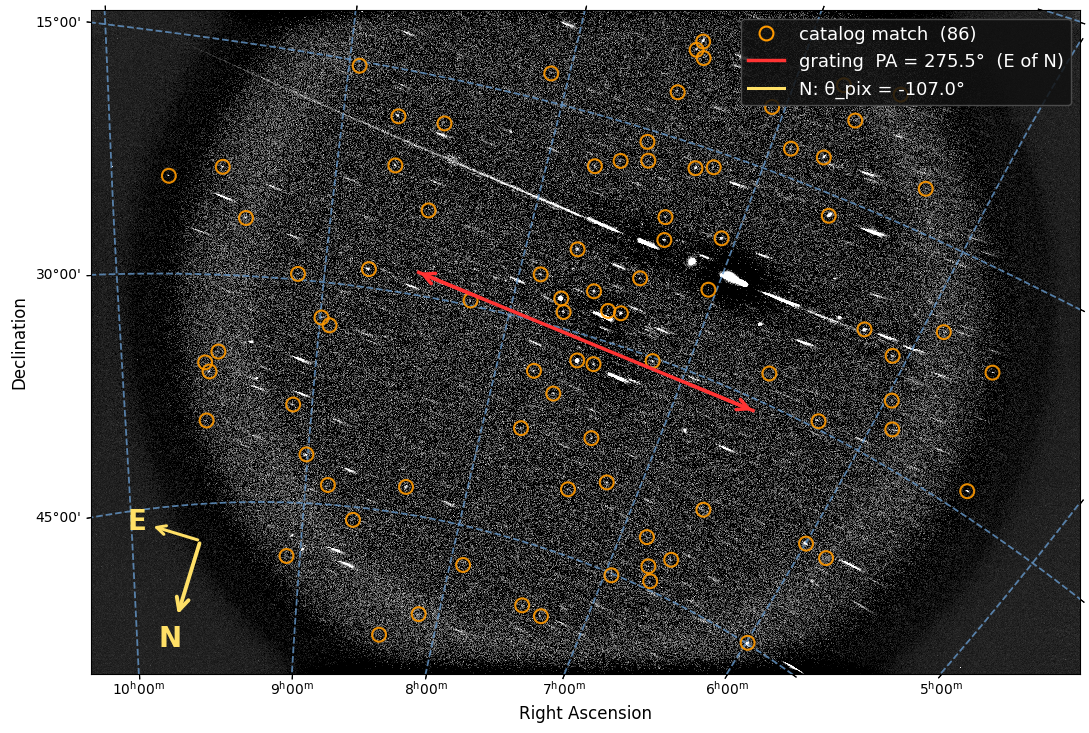

Saved → /mnt/c/Users/bassd/Research/Spectra Angle/spectrangle/out/proposal_fig_real/proposal_real_v2.png


In [43]:
plt.rcParams.update({
    'font.family': 'sans-serif',
    'figure.facecolor':  'white',
    'savefig.facecolor': 'white',
    'savefig.dpi': FIG_DPI,
})

# Suppress WCS inversion convergence warnings from WCSAxes grid drawing
warnings.filterwarnings('ignore',
    message=r".*all_world2pix.*", category=UserWarning,
    module=r'astropy\.wcs')

fig = plt.figure(figsize=(FIG_W, FIG_H))
fig.patch.set_facecolor('white')
ax  = fig.add_subplot(1, 1, 1, projection=wcs)
ax.set_facecolor('black')

# Image
ax.imshow(disp, origin='lower', cmap=CMAP,
          vmin=0, vmax=1, aspect='equal', interpolation='nearest')

# WCS grid
ax.coords.grid(True, color=GRID_COLOR, alpha=GRID_ALPHA, linestyle='--', linewidth=GRID_LW)
ax.coords['ra'].set_major_formatter('hh:mm')
ax.coords['dec'].set_major_formatter('dd:mm')
ax.coords['ra'].set_axislabel('Right Ascension', fontsize=12, color='black')
ax.coords['dec'].set_axislabel('Declination',    fontsize=12, color='black')
ax.coords['ra'].set_ticklabel(color='black', size=10)
ax.coords['dec'].set_ticklabel(color='black', size=10)
ax.coords['ra'].set_ticks(color='black')
ax.coords['dec'].set_ticks(color='black')

# Matched source circles
pix = ax.get_transform('pixel')
if len(mx):
    ax.scatter(mx, my, transform=pix,
               s=MATCH_SZ, facecolors='none', edgecolors=MATCH_COLOR,
               linewidths=MATCH_LW, alpha=0.90, zorder=4)

# Compass
draw_compass(ax, compass_x, compass_y, compass_L)

# Grating angle double-headed arrow
draw_grating_arrow(ax, grating_x, grating_y, grating_L, grating_pix_ang)

# Legend
handles = [
    Line2D([0], [0], marker='o', color='none',
           markerfacecolor='none', markeredgecolor=MATCH_COLOR,
           markeredgewidth=MATCH_LW, markersize=10,
           label=f'catalog match  ({len(mx)})'),
    Line2D([0], [0], color=GRATING_COLOR, linewidth=2.5,
           label=f'grating  PA = {GRATING_PA_SKY:.1f}°  (E of N)'),
    Line2D([0], [0], color=COMPASS_COLOR, linewidth=2.2,
           label=f'N: θ_pix = {metrics.north_angle_deg:.1f}°'),
]
ax.legend(handles=handles, fontsize=13, loc='upper right',
          facecolor='#111111', edgecolor='#555555',
          labelcolor='white', framealpha=0.85)

fig.tight_layout()
fig.savefig(FIG_OUT, bbox_inches='tight')
plt.show()
print(f'Saved → {FIG_OUT.resolve()}')


In [42]:
# ── Stretch ───────────────────────────────────────────────────────────────────
LO_PCT = 30.0   # percentile → black  (raise = darker sky, lower = show faint stars)
HI_PCT = 99.8   # percentile → white  (lower = clip bright stars)
GAMMA  = 0.75    # 0.5=sqrt (bright), 1.0=linear, 0.3=aggressive

# ── Grating angle ─────────────────────────────────────────────────────────────
GRATING_PA_SKY = 275.5   # degrees east of north (sky coords)

# ── Compass position & size ───────────────────────────────────────────────────
COMPASS_X_FRAC   = 0.11   # base x  (fraction of image width)
COMPASS_Y_FRAC   = 0.2   # base y  (fraction of image height)
COMPASS_LEN_FRAC = 0.12   # N-arrow length  (fraction of min(nx, ny))

# ── Grating arrow position & size  (independent of compass) ──────────────────
#GRATING_X_FRAC   = 0.61   # centre x  (fraction of image width)
#GRATING_Y_FRAC   = 0.62   # centre y  (fraction of image height)
GRATING_X_FRAC   = 0.5   # centre x  (fraction of image width)
GRATING_Y_FRAC   = 0.5   # centre y  (fraction of image height)
GRATING_LEN_FRAC = 0.55   # total arrow length  (fraction of min(nx, ny))

# ── WCS grid appearance ───────────────────────────────────────────────────────
GRID_ALPHA = 0.80   # grid line opacity  (0=invisible, 1=solid)
GRID_LW    = 1.3    # grid line width (pt)

# ── Derived — consumed by Cell 3 ─────────────────────────────────────────────
disp            = _stretch(LO_PCT, HI_PCT, GAMMA)
grating_pix_ang = sky_pa_to_pixel_angle(GRATING_PA_SKY)
compass_x  = nx * COMPASS_X_FRAC
compass_y  = ny * COMPASS_Y_FRAC
compass_L  = min(nx, ny) * COMPASS_LEN_FRAC
grating_x  = nx * GRATING_X_FRAC
grating_y  = ny * GRATING_Y_FRAC
grating_L  = min(nx, ny) * GRATING_LEN_FRAC

print(f'Stretch : p{LO_PCT} – p{HI_PCT},  gamma={GAMMA}')
print(f'Grating : {GRATING_PA_SKY}° (sky)  →  {grating_pix_ang:.2f}° (pixel CCW from +x)')
print(f'Compass : base=({compass_x:.0f}, {compass_y:.0f}) px,  L={compass_L:.0f} px')
print(f'Grating : centre=({grating_x:.0f}, {grating_y:.0f}) px,  L={grating_L:.0f} px')

# ── Angle-math sanity check: PA 0/90/180/270 must exactly recover N/E/S/W ────
_checks = [(0,   metrics.north_angle_deg,        'N'),
           (90,  metrics.east_angle_deg,          'E'),
           (180, metrics.north_angle_deg + 180,   'S'),
           (270, metrics.east_angle_deg  - 180,   'W')]
print('\nAngle-math check:')
for pa, expected, lbl in _checks:
    got  = sky_pa_to_pixel_angle(pa)
    err  = abs(((got - expected + 180) % 360) - 180)
    print(f'  PA={pa:3d}° ({lbl}) → pix={got:8.3f}°   expected={expected:.3f}°   err={err:.4f}°')


Stretch : p30.0 – p99.8,  gamma=0.75
Grating : 275.5° (sky)  →  -22.46° (pixel CCW from +x)
Compass : base=(341, 416) px,  L=250 px
Grating : centre=(1548, 1040) px,  L=1144 px

Angle-math check:
  PA=  0° (N) → pix=-107.006°   expected=-107.006°   err=0.0000°
  PA= 90° (E) → pix= 163.039°   expected=163.039°   err=0.0000°
  PA=180° (S) → pix=  72.994°   expected=72.994°   err=0.0000°
  PA=270° (W) → pix= -16.961°   expected=-16.961°   err=0.0000°
